In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Loading data
map_14_18 = pd.read_csv("../data/data_edited/wildfire_14_18.csv", sep = ",")
map_19_23 = pd.read_csv("../data/data_edited/wildfire_19_23.csv", sep = ",")

print("Data loaded successfully")

Data loaded successfully


In [2]:
# Load Canada data
canada = gpd.read_file("../data/lpr_000b21a_e.zip")
print("Zip loaded successfully")

# Check which crs the data has
print(canada.crs)

# Reproject to epsg:4326
canada = canada.to_crs(epsg = 4326)

Zip loaded successfully
EPSG:3347


In [3]:
# Generate points
geometry_14_18 = gpd.points_from_xy(
    map_14_18["longitude"],
    map_14_18["latitude"]
)

# Make GeoDataFrame
map_14_18_gpd = gpd.GeoDataFrame(
    map_14_18,
    geometry=geometry_14_18,
    crs="EPSG:4326"
)

map_14_18_gpd.crs == canada.crs

True

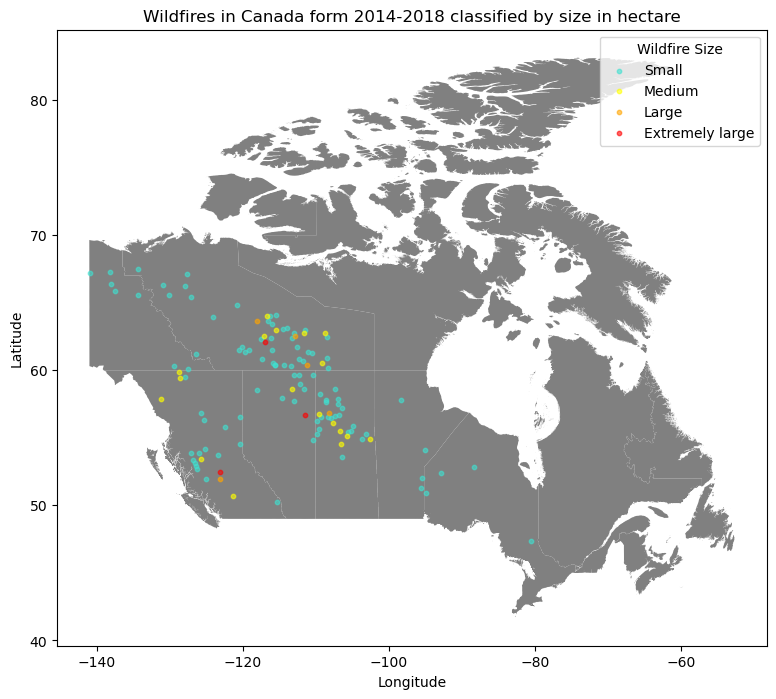

In [4]:
# Map
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the GeoDataFrame directly onto our specific Axes
canada.plot(ax=ax, color="grey")

colors = {"Small":"turquoise",
          "Medium":"yellow",
          "Large":"orange",
          "Extremely large":"red"       
}

# Plot each class seperatly
for category, color in colors.items():

    subset = map_14_18_gpd[
        map_14_18_gpd["size"] == category
    ]

    subset.plot(
        ax=ax,
        color=color,
        markersize=10,
        alpha=0.6,
        label=category
    )

# Legende
ax.legend(title="Wildfire Size")

# Apply geographic context to the axes
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Wildfires in Canada form 2014-2018 classified by size in hectare")

plt.show()

In [5]:
# Generate points
geometry_19_23 = gpd.points_from_xy(
    map_19_23["longitude"],
    map_19_23["latitude"]
)

# Make GeoDataFrame
map_19_23_gpd = gpd.GeoDataFrame(
    map_19_23,
    geometry=geometry_19_23,
    crs="EPSG:4326"
)

map_19_23_gpd.crs == canada.crs

True

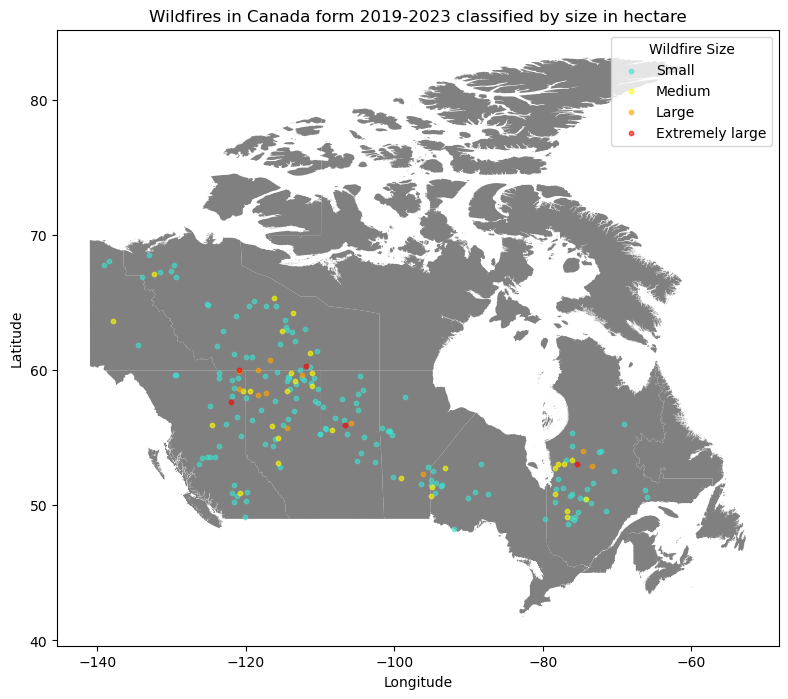

In [6]:
# Map
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the GeoDataFrame directly onto our specific Axes
canada.plot(ax=ax, color="grey")

colors = {"Small":"turquoise",
          "Medium":"yellow",
          "Large":"orange",
          "Extremely large":"red"       
}

# Plot each class seperatly
for category, color in colors.items():

    subset = map_19_23_gpd[
        map_19_23_gpd["size"] == category
    ]

    subset.plot(
        ax=ax,
        color=color,
        markersize=10,
        alpha=0.6,
        label=category
    )

# Legende
ax.legend(title="Wildfire Size")

# Apply geographic context to the axes
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Wildfires in Canada form 2019-2023 classified by size in hectare")

plt.show()

In [7]:
# Interactive map
import folium
import branca

# Using athe basemap Jawg.Sunny from Jawaglab
tile_url = "https://tile.jawg.io/jawg-sunny/{z}/{x}/{y}.png?access-token=tniPiJQZVj5mGbfqOx8aIkfbRAIb4oLMomGVDcYNw07EFi13vUfu7z5GRFLN6Al9"

attribution = ('<a href="https://jawg.io" title="Tiles Courtesy of Jawg Maps" target="_blank">&copy; <b>Jawg</b>Maps</a> &copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors'

)

# Create Folium map object
m = folium.Map(
    location=[62, -98],
    zoom_start=4,
    tiles=None
)

# Basemap with pretty name
folium.TileLayer(tiles=tile_url,
                 attr=attribution,
                 name="Basemap sunny"
).add_to(m)

#colors

def get_colors_size(size):

    colors_size = {
        "Very small": "blue",
        "Small": "turquoise",
        "Medium": "yellow",
        "Large": "orange",
        "Extremely large": "red"
    }

    return colors_size.get(size, "gray")

# Create layers
# Layers for 2014-2018
map_14_18_other = folium.FeatureGroup(
    name= "2014 - 2018: Small - Extremely Large Wildfires",
    show=True
)

map_14_18_very_small = folium.FeatureGroup(
    name="2014 - 2018: Very Small Wildfires",
    show=False
)

# Layer for 2019-2023
map_19_23_other = folium.FeatureGroup(
    name="2019 - 2023: Small - Extremely Large Wildfires",
    show=True
)

map_19_23_very_small = folium.FeatureGroup(
    name="2019 - 2023: Very Small Wildfires",
    show=False
)

def add_wildfire_points(gdf, very_small, other, dataset_name):

    for _, row in gdf.iterrows():

        size = str(row["size"]).strip()


        marker=folium.CircleMarker(
            location=[row.geometry.y, row.geometry.x],
            radius=5,
            color=get_colors_size(size),
            fill=True,
            fill_color=get_colors_size(size),
            fill_opacity=0.9,
            weight=1,
            tooltip=(
                f"Province: {row['province']}<br>"
                f"Fire ID: {row['fire_id']}<br>"
                f"Starting Year: {row['year']}<br>"
                f"Cause: {row['cause']}<br>"
                f"Size [ha]: {row['size_ha']}<br>"
            )
        )

        if size =="Very small":
            marker.add_to(very_small)

        else:
            marker.add_to(other)

# Add Datasets
# For 2014-2018
add_wildfire_points(
    map_14_18_gpd,
    map_14_18_very_small,
    map_14_18_other,
    "Wildfires 2014 - 2018"
)

# For 2019-2023
add_wildfire_points(
    map_19_23_gpd,
    map_19_23_very_small,
    map_19_23_other,
    "Wildfires 2019 - 2023"
)

# Add to map
map_14_18_very_small.add_to(m)
map_14_18_other.add_to(m)

map_19_23_very_small.add_to(m)
map_19_23_other.add_to(m)


# Add the interactive layer control menu to the top right corner
folium.LayerControl().add_to(m)

# Legend
legend_html = """
<div style="
    position: fixed;
    bottom: 50px;
    left: 50px;
    width: 150px;
    background-color: white;
    border:1px solid grey;
    z-index:9999;
    font-size:14px;
    padding: 12px;
">

<b>Wildfire Size</b><br><br>

<div><span style="color:blue;">⬤</span> Very Small</div>
<div><span style="color:cyan;">⬤</span> Small</div>
<div><span style="color:gold;">⬤</span> Medium</div>
<div><span style="color:orange;">⬤</span> Large</div>
<div><span style="color:red;">⬤</span> Extremely Large</div>

</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

m